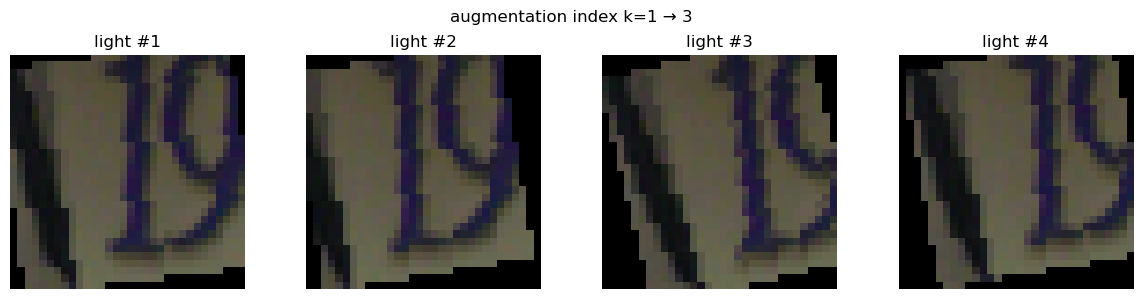

In [3]:
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms


def get_transforms(augmentation="none"):
    normalize = transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))

    if augmentation == "none":
        train_transform = transforms.Compose([
            transforms.ToTensor(),
            normalize,
        ])
    elif augmentation == "light":
        train_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            normalize,
        ])
    elif augmentation == "color":
        train_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            normalize,
        ])
    else:
        raise ValueError(f"不支持的数据增强模式: {augmentation}")

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])
    return train_transform, test_transform


AUG_BY_INDEX = ("none", "light", "color")


def denormalize_svhn(t):
    # 与 get_transforms 里 Normalize(0.5, 0.5) 对应
    return t * 0.5 + 0.5


def show_augmentation_effect(k, index_in_dataset=0, root_path="./svhn_cropped", n_samples=4, seed=None):
    """k: 0=none, 1=light, 2=color；展示该增强下 n_samples 次随机结果"""
    assert k in (0, 1, 2), "k 应为 0、1 或 2"
    mode = AUG_BY_INDEX[k]
    train_t, _ = get_transforms(mode)

    raw = torchvision.datasets.SVHN(root=root_path, split="train", download=False, transform=None)
    pil_img = raw[index_in_dataset][0]  # PIL, 未增强

    fig, axes = plt.subplots(1, n_samples, figsize=(3 * n_samples, 3))
    if n_samples == 1:
        axes = [axes]
    for i in range(n_samples):
        if seed is not None:
            torch.manual_seed(seed + i)  # 仅部分随机算子会受此影响
        x = train_t(pil_img)
        img = denormalize_svhn(x).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(f"{mode} #{i+1}")
        axes[i].axis("off")
    plt.suptitle(f"augmentation index k={k} → 3")
    plt.tight_layout()
    plt.show()


# 示例：只看「数字 1」对应 light 的 4 张随机增强
show_augmentation_effect(1, index_in_dataset=0, n_samples=4)


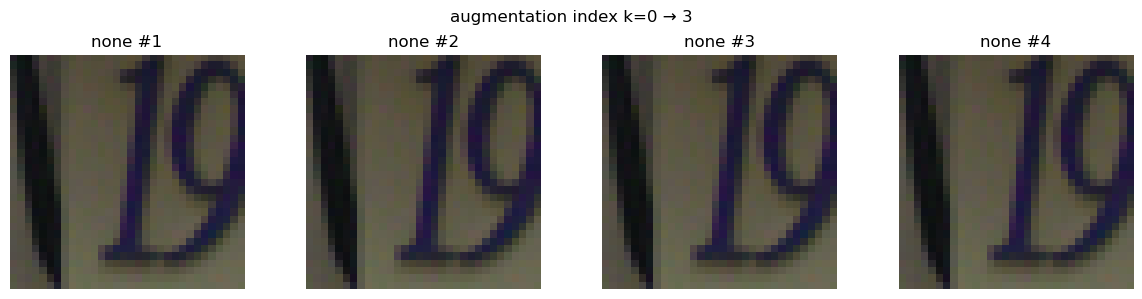

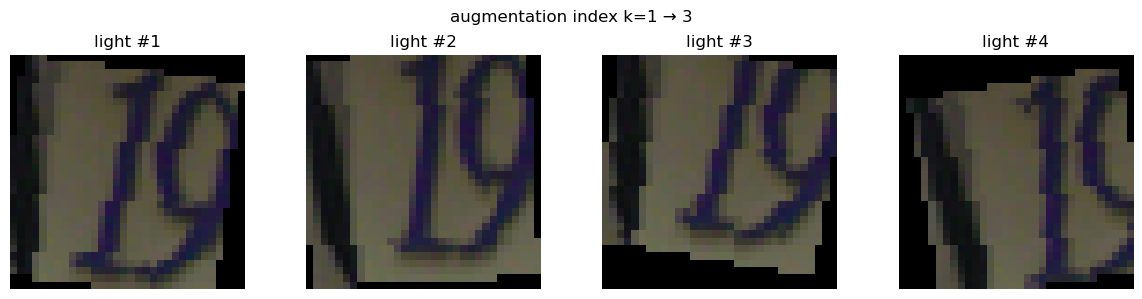

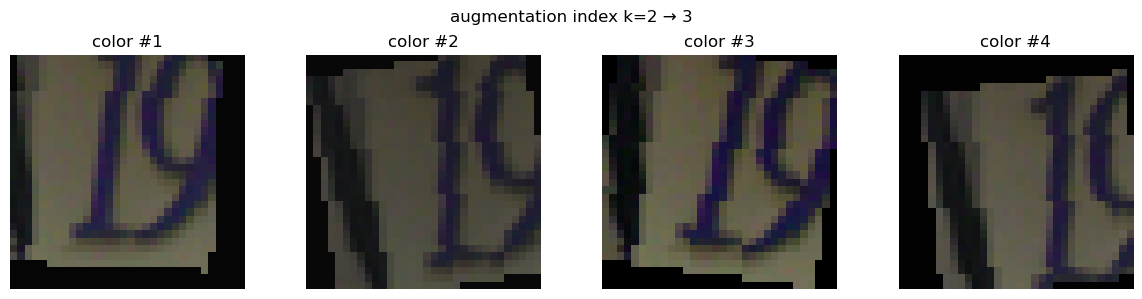

In [4]:
for k in range(3):
    show_augmentation_effect(k, index_in_dataset=0, n_samples=4)